# Hitting Times

A **hitting time** answers one question: *how long until this random process
first reaches some level?*

- How long until a stock first touches \$120?
- How long until a gambler is up \$50?
- How long until an insurer's reserves first hit \$0? (*ruin*)

`hitting_time(process, level=...)` gives you the answer as a random variable,
which you can then simulate, plot, and summarize like anything else.

In [1]:
from symbulate import *
import matplotlib.pyplot as plt

## Simulate some paths and pick a level

Below are five paths of a Brownian motion -- a random wander that starts at 0.
The dashed line is the level 1. For each path, the hitting time is the first
moment it touches that line. Some paths get there quickly, some late, and some
never get there at all.

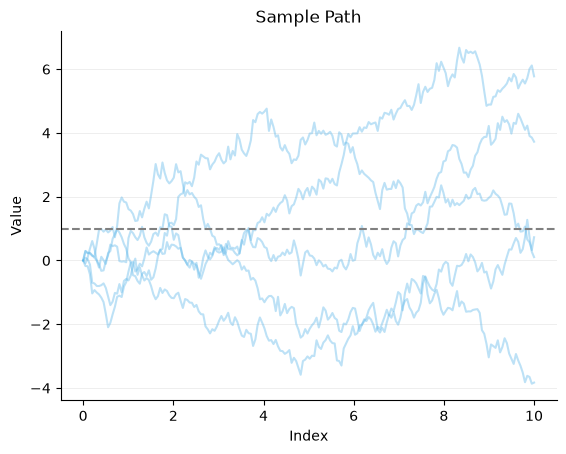

In [2]:
B = BrownianMotion()

B.sim(5).plot(tmin=0, tmax=10)
plt.axhline(1, color="gray", linestyle="--");

## Ask for the hitting time

`max_time` is how long to keep looking before giving up. You need it because
the level might never be reached, and in that case the honest answer is `inf`
(infinity).

The result is a random variable, so simulate it. Each value is how long that
one path took to reach 1.

In [3]:
T = hitting_time(B, level=1, max_time=20)

times = T.sim(1000)
times

0,inf
1,0.21562538146972657
2,1.7874996185302732
3,1.1275707244873048
4,0.6999996185302735
5,0.9691371917724608
6,0.9437496185302734
7,0.3170055389404297
8,inf
...,...
999,2.101562118530273


Look closely and some of those values are `inf`: those paths never got to 1
within the 20 units of time we allowed. That is not a failure, it is a real
feature of hitting times -- some paths simply wander the wrong way the whole
time.

So the first thing to report is how many paths arrived at all.

In [4]:
print(f"reached level 1 within 20:  {times.count_leq(20)} of 1000 paths")

reached level 1 within 20:  815 of 1000 paths


## The shape of the distribution

To plot only the paths that arrived, drop the infinities first with
`filter_leq`. Most paths reach the level early, but the tail is very long -- a
few take almost the whole window.

Currently Showing: Histogram (Default)
Alternative Plots: Rug Plot (type = "rug"), Density Plot (type = "density"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


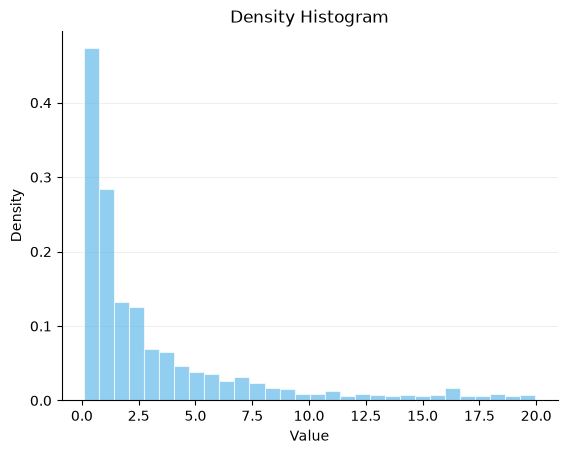

In [5]:
times.filter_leq(20).plot()

That tail is so long that the **average is infinite** -- not merely large,
actually infinite. Symbulate reports that honestly:

In [6]:
times.mean()

inf

So quote the **median** of the paths that arrived instead. Half of them got
there faster than this, half slower.

In [7]:
times.filter_leq(20).median()

1.4062496185302735

## Checking it against a known answer

Brownian motion is one of the few processes where the answer is known on paper.
The chance of reaching level `a` by time `t` is exactly `2 * Phi(-a / sqrt(t))`,
where `Phi` is the normal CDF -- the `.cdf` of a standard `Normal`. Simulation
and formula agree:

In [8]:
Z = Normal(mean=0, sd=1)

for max_time in [1, 4, 16]:
    reached = hitting_time(B, level=1, max_time=max_time).sim(2000).count_leq(max_time)
    exact = 2 * Z.cdf(-1 / max_time**0.5)
    print(f"by time {max_time:>2}:  simulated {reached / 2000:.3f}   exact {exact:.3f}")

by time  1:  simulated 0.319   exact 0.317


by time  4:  simulated 0.612   exact 0.617


by time 16:  simulated 0.797   exact 0.803


## Compare with a process that drifts upward

The answer belongs to the process, not just to the level. `BrownianMotion` with
no drift has no reason to prefer up over down, which is why so many paths never
arrive. Give it a steady upward push and almost all of them do.

In [9]:
drifting = hitting_time(BrownianMotion(drift=1), level=1, max_time=20).sim(1000)

print(f"no drift, reached 1 within 20:  {times.count_leq(20)} of 1000")
print(f"drift 1,  reached 1 within 20:  {drifting.count_leq(20)} of 1000")

no drift, reached 1 within 20:  815 of 1000
drift 1,  reached 1 within 20:  1000 of 1000


## Falling to a level works too

You never say which direction. If the path starts *below* the level,
`hitting_time` looks for the first time it rises to it; if it starts *above*,
the first time it falls to it. Brownian motion starts at 0, so level -1 means
falling. By symmetry, reaching -1 should be just as likely as reaching +1.

In [10]:
up = hitting_time(B, level=1, max_time=4).sim(2000)
down = hitting_time(B, level=-1, max_time=4).sim(2000)

print(f"reached +1 within 4:  {up.count_leq(4)} of 2000")
print(f"reached -1 within 4:  {down.count_leq(4)} of 2000")

reached +1 within 4:  1210 of 2000
reached -1 within 4:  1274 of 2000


## A more realistic question

Put it together with a stock price. A share is worth \$100 today and you want
to sell at \$120. How long might that take?

In [11]:
stock = GeometricBrownianMotion(initial_value=100, growth_rate=0.05, scale=0.3)
wait = hitting_time(stock, level=120, max_time=10).sim(1000)

print(f"hit $120 within 10 years:  {wait.count_leq(10)} of 1000")
print(f"median wait, if it did:    {wait.filter_leq(10).median():.2f} years")

hit $120 within 10 years:  870 of 1000
median wait, if it did:    0.67 years


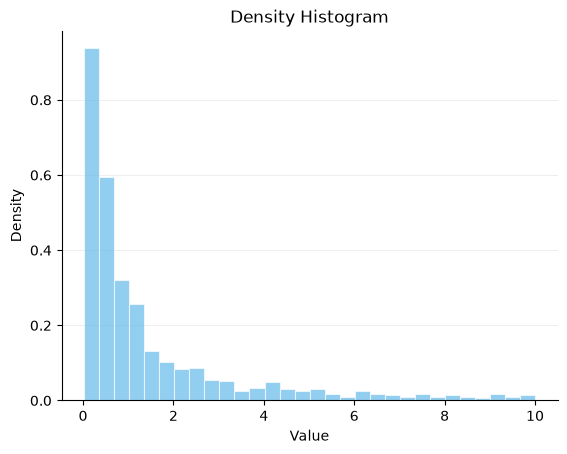

In [12]:
wait.filter_leq(10).plot()

## Why this needs more than a simple scan

Here is the catch, and it is the whole reason this needs a real algorithm
rather than a loop.

A sample path is only ever worked out at the times you ask about. In between
two of those times it is **not** a straight line -- it wiggles. So the path can
pop above the level and come back down without either of the times you looked
at noticing.

Take one path and look at it more and more finely, each time reporting the
highest value seen:

In [13]:
path = BrownianMotion().draw()

for step in [2, 0.5, 0.01]:
    checked = [step * i for i in range(int(10 / step) + 1)]
    print(f"checking every {step:>4}:  highest value seen is {max(path(t) for t in checked):.2f}")

checking every    2:  highest value seen is 2.58
checking every  0.5:  highest value seen is 2.92


checking every 0.01:  highest value seen is 3.21


The number never goes down as you look more finely, and it usually goes up.
Every increase is somewhere the path went that the coarser check walked
straight past -- so any level in between was reached without being noticed.
Looking more finely always finds more, and you can never be sure you have
looked finely enough. A plain scan would report hitting times that are **too
late**, or miss crossings completely.

`hitting_time` avoids the problem instead of out-running it. For a Brownian
motion there is a formula for the *probability* that the path crossed a level
between two values you do know. So rather than looking harder, it flips a coin
weighted by that probability, and nothing can hide. When the coin says a
crossing happened, it cuts the stretch in half over and over to work out when.
The formula and the details are in `symbulate/hitting_times.py`.

## Three things to know

**1. `step` controls precision, not just speed.** `step` is how far ahead the
search looks at a time. Whether the level was reached, and which `step`-sized
stretch it happened in, is exact for Brownian motion. But pinning down *where
inside* that stretch is approximate and leans slightly late, so the reported
time is good to about one `step`. The default (the search window split into
100) is fine for plotting a distribution; use a smaller `step` if you need
sharp individual times.

**2. `start_time` looks for a later crossing.** A hitting time is the *first*
time the level is reached. Pass `start_time` to begin the search later on --
just past an earlier crossing, say -- and you get the next one instead.

**3. Only Gaussian processes so far.** `BrownianMotion`, `BrownianBridge`,
`OrnsteinUhlenbeck`, `FractionalBrownianMotion`, `GeometricBrownianMotion`, and
any `GaussianProcess` you build yourself. For Brownian motion and Brownian
bridges the crossing formula is exact; for the others it is a close
approximation that improves with a smaller `step`.

Other kinds of process -- random walks, Markov chains, queues, general
diffusions -- need different handling and are not built yet. Asking anyway
gives a clear message rather than a wrong number:

In [14]:
try:
    hitting_time(RandomWalk(p=0.5).draw(), level=5)
except NotImplementedError as error:
    print(error)

hitting_time currently only works for Gaussian processes -- BrownianMotion, BrownianBridge, OrnsteinUhlenbeck, FractionalBrownianMotion, GeometricBrownianMotion, or a GaussianProcess you built yourself. It was given a RandomWalkResult, which needs different handling: a discrete-time or jump process (a random walk, Markov chain, or queue) can be checked step by step, and a DiffusionProcess needs its own approximation. Neither is built yet.
